# Exercice 2.1 : Partitionnement avec K-Means
Dans cet atelier, nous modifions manuellement le nombre de groupes K pour observer visuellement comment le trafic se sépare.

#### 1. Chargement et normalisation rapide

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.decomposition import PCA

data = pd.read_csv('data/UNSW_NB15_training-set.csv')
features = data.copy()
for col in features.select_dtypes(include=['object']).columns:
    features[col] = LabelEncoder().fit_transform(features[col].astype(str))

#X_scaled = features
X_scaled = StandardScaler().fit_transform(features)

# Projection 2D pour visualiser les clusters
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
print("Données prêtes :", X_scaled.shape)

C:\Users\Lucas\AppData\Local\Temp\ipykernel_32448\2193531534.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in features.select_dtypes(include=['object']).columns:


Données prêtes : (82332, 45)


#### 2. K-Means avec plusieurs K : Observez la séparation

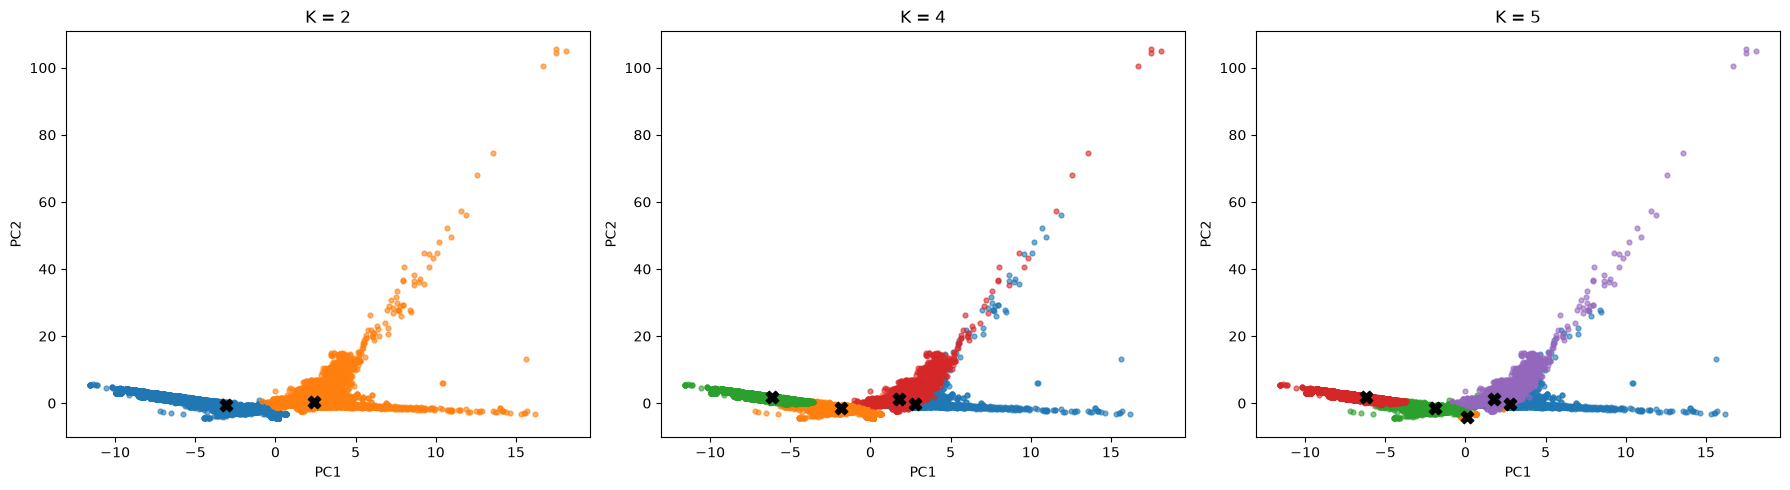

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

ks = [2, 4, 5]

fig, axes = plt.subplots(1, len(ks), figsize=(18, 5))

for ax, K in zip(axes, ks):
    km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_scaled)
    centroids = PCA(n_components=2, random_state=42).fit(X_scaled).transform(km.cluster_centers_)

    for cluster in range(K):
        mask = km.labels_ == cluster
        ax.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            s=12,
            alpha=0.6,
            c=[plt.cm.tab10(cluster % 10)],
        )

    ax.scatter(
        centroids[:, 0],
        centroids[:, 1],
        c='black',
        marker='X',
        s=80,
        label='centroids'
    )
    ax.set_title(f"K = {K}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(False)

plt.tight_layout()
plt.show()

#### 5. Profilage cyber : Qui sont ces groupes ?

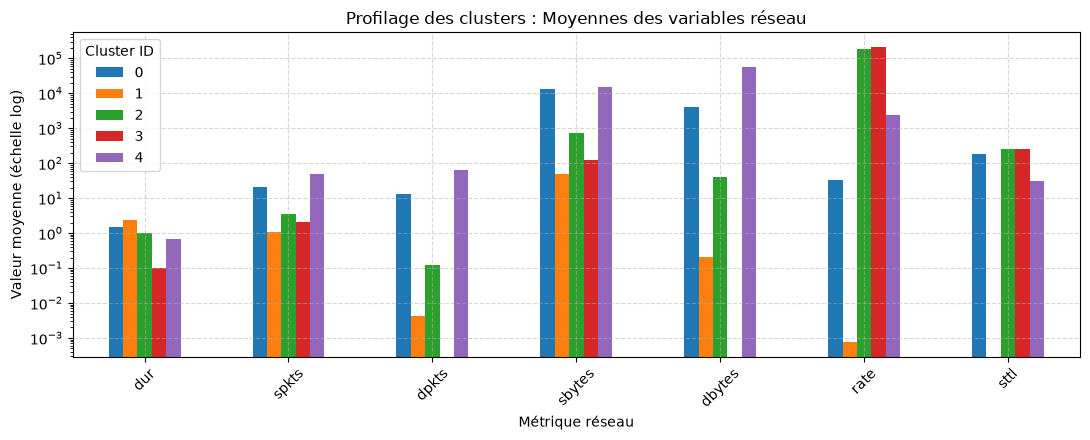

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl
0,1.510991,20.970179,12.835550,12908.837524,4042.432114,32.453250,187.998615
1,2.339655,1.039387,0.004376,47.733042,0.201313,0.000753,0.000000
2,0.976459,3.523333,0.125692,726.913442,39.624636,183159.916996,251.783884
3,0.097147,2.042707,0.000000,126.645086,0.000000,209370.027190,254.000000
4,0.676040,47.745886,62.269349,15460.112287,56513.138803,2371.654362,31.894924


In [3]:
from helper import plot_cluster_profiling

K=5
km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_scaled)
# Moyennes des variables clés par groupe
cols = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl']
profil = data[cols].groupby(km.labels_).mean()

plot_cluster_profiling(profil)
profil

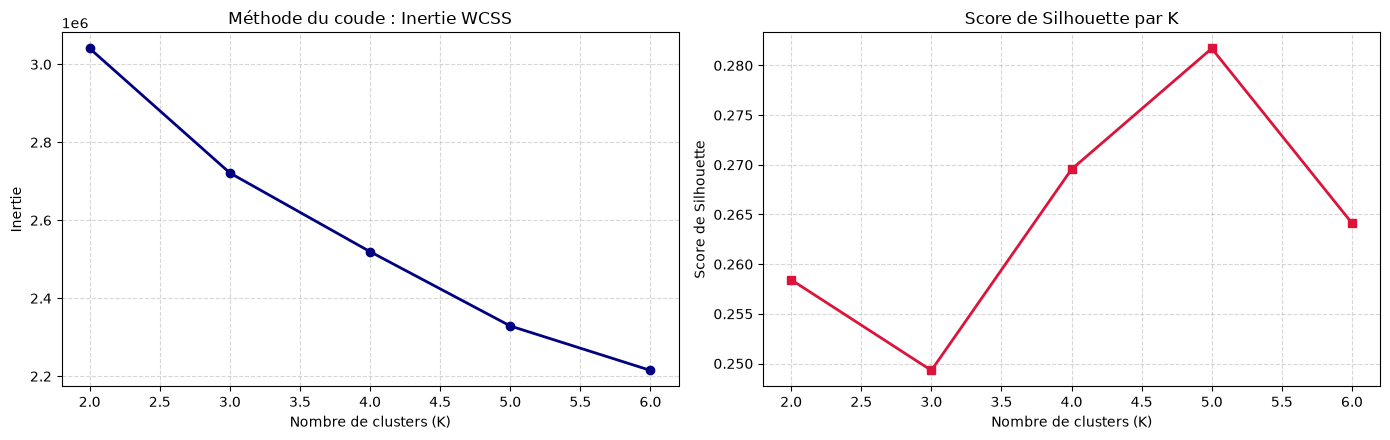

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from helper import plot_clustering_metrics

k_range = range(2, 7)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_, sample_size=2000, random_state=42))

plot_clustering_metrics(k_range, inertias, silhouettes)

# À faire :
1. Est-ce que changer standard et robust scaler changent-il le meilleur K? 
0,5 avec Robust et 0,7 avec Standard e
2. Extraire les clusters, assigner à chaque ligne sa valeur, et comparer contre les vrais données.

In [9]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report

# pca = PCA(n_components=0.90, random_state=42)
# X_pca = pca.fit_transform(X_scaled)

# 1. Clustering
km = KMeans(n_clusters=2, random_state=42, n_init=10) # 2 groupes, 
clusters = km.fit_predict(X_scaled)
y_true = data["label"].values

# 2. Identifier la vraie classe majoritaire dans le cluster 0
# Si la majorité du cluster 0 est la classe 1, alors les rôles sont inversés
majority_in_cluster_0 = pd.Series(y_true[clusters == 0]).mode()[0] # Permet de ne pas avoir 0 = menace

if majority_in_cluster_0 == 1:
    y_pred = 1 - clusters  # Les rôles étaient inversés
else:
    y_pred = clusters      # Les rôles étaient déjà bons

# 3. Évaluation réelle (reflète la vraie performance, même si elle est mauvaise)
print("Accuracy réelle :", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, zero_division=0))

Accuracy réelle : 0.7374289462177526
              precision    recall  f1-score   support

           0       0.67      0.83      0.74     37000
           1       0.83      0.66      0.73     45332

    accuracy                           0.74     82332
   macro avg       0.75      0.75      0.74     82332
weighted avg       0.76      0.74      0.74     82332



In [6]:
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

K = 3  # Choisir la valeur de K ici

# 1. Calcul PCA 3D
pca = PCA(n_components=3, random_state=42)
X_3d = pca.fit_transform(X_scaled)

# 2. Entraînement K-Means
km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_scaled)

# 3. Projection des centroïdes dans le même espace PCA 3D
centroids_3d = pca.transform(km.cluster_centers_)

# 4. Tracé Plotly 3D
fig = go.Figure()

# Points du jeu de données colorés par cluster
fig.add_trace(
    go.Scatter3d(
        x=X_3d[:, 0],
        y=X_3d[:, 1],
        z=X_3d[:, 2],
        mode="markers",
        marker=dict(
            size=3,
            color=km.labels_,
            colorscale="Viridis",
            opacity=0.6,
        ),
        name="Données",
    )
)

# Centroïdes
fig.add_trace(
    go.Scatter3d(
        x=centroids_3d[:, 0],
        y=centroids_3d[:, 1],
        z=centroids_3d[:, 2],
        mode="markers",
        marker=dict(
            size=8,
            color="red",
            symbol="x",
        ),
        name="Centroïdes",
    )
)

fig.update_layout(
    title=f"Clustering K-Means (K = {K}) sur PCA 3D",
    scene=dict(
        xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)",
        yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)",
        zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f} %)",
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()